In [99]:
import pandas as pd
import numpy as np

# If this import fails, install statsmodels:
# !pip install statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------- 1. LOAD HISTORICAL NET MIGRATION -------------
# This is the file created by your earlier aggregation code
df = pd.read_excel("metro_migration_net_2011_2022.xlsx")

# Keep only the metros we care about
target_metros = ["Atlanta", "Chicago", "Dallas", "Houston", "Minneapolis", "Phoenix"]
df = df[df["metro"].isin(target_metros)].copy()

# Clean types
df["year"] = df["year"].astype(int)
df["net_n1"] = pd.to_numeric(df["net_n1"], errors="coerce")

# Sanity check
print("Historical data sample:")
print(df.head())

Historical data sample:
   year    metro  cbsa_code  inflow_n1  outflow_n1  net_n1
0  2012  Atlanta      12060     883953      859266   24687
1  2013  Atlanta      12060     831591      802282   29309
2  2014  Atlanta      12060     774438      736385   38053
3  2015  Atlanta      12060     625011      584046   40965
4  2016  Atlanta      12060     801770      734673   67097


In [100]:
# ------------- 2. AUTO ARIMA FORECAST -------------

import pmdarima as pm
import matplotlib.pyplot as plt

# Ensure numeric columns
for col in ["inflow_n1", "outflow_n1", "net_n1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

future_years = [2023, 2024, 2025, 2026, 2027]
records = []

for metro in sorted(df["metro"].unique()):
    sub = df[df["metro"] == metro].sort_values("year").copy()

    years_hist = sub["year"].values
    y = sub["net_n1"].values

    # ---- Auto-ARIMA on net_n1 ----
    model = pm.auto_arima(
        y,
        start_p=1, start_q=1,
        max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )

    fitted = model.predict_in_sample()                 # 2011–2022 fitted
    fc = model.predict(n_periods=len(future_years))    # 2023–2027 forecast

    # ---- Historical rows ----
    for year, inflow, outflow, actual, fit in zip(
        years_hist,
        sub["inflow_n1"].values,
        sub["outflow_n1"].values,
        sub["net_n1"].values,
        fitted,
    ):
        if actual != 0 and not np.isnan(actual):
            err_pct = abs(actual - fit) / abs(actual) * 100
        else:
            err_pct = np.nan

        records.append({
            "metro": metro,
            "year": int(year),
            "inflow": float(inflow) if not np.isnan(inflow) else np.nan,
            "outflow": float(outflow) if not np.isnan(outflow) else np.nan,
            "actual_net_n1": float(actual),
            "arima_net_n1": float(fit),
            "error_pct": float(err_pct),
            "is_forecast": 0
        })

    # ---- Future rows ----
    for year, fc_val in zip(future_years, fc):
        records.append({
            "metro": metro,
            "year": int(year),
            "inflow": np.nan,
            "outflow": np.nan,
            "actual_net_n1": np.nan,
            "arima_net_n1": float(fc_val),
            "error_pct": np.nan,
            "is_forecast": 1
        })

df_arima = (
    pd.DataFrame(records)
    .sort_values(["metro", "year"])
    .reset_index(drop=True)
)

print(df_arima.head())

     metro  year    inflow   outflow  actual_net_n1  arima_net_n1  error_pct  \
0  Atlanta  2012  883953.0  859266.0        24687.0  45245.175915  83.275311   
1  Atlanta  2013  831591.0  802282.0        29309.0  37071.822124  26.486138   
2  Atlanta  2014  774438.0  736385.0        38053.0  38909.399610   2.250544   
3  Atlanta  2015  625011.0  584046.0        40965.0  42385.768615   3.468250   
4  Atlanta  2016  801770.0  734673.0        67097.0  43543.498092  35.103659   

   is_forecast  
0            0  
1            0  
2            0  
3            0  
4            0  


In [101]:
out_file = "metro_migration_arima_2011_2027.xlsx"
df_arima.to_excel(out_file, index=False)
print(f"Saved ARIMA migration forecast to: {out_file}")

Saved ARIMA migration forecast to: metro_migration_arima_2011_2027.xlsx


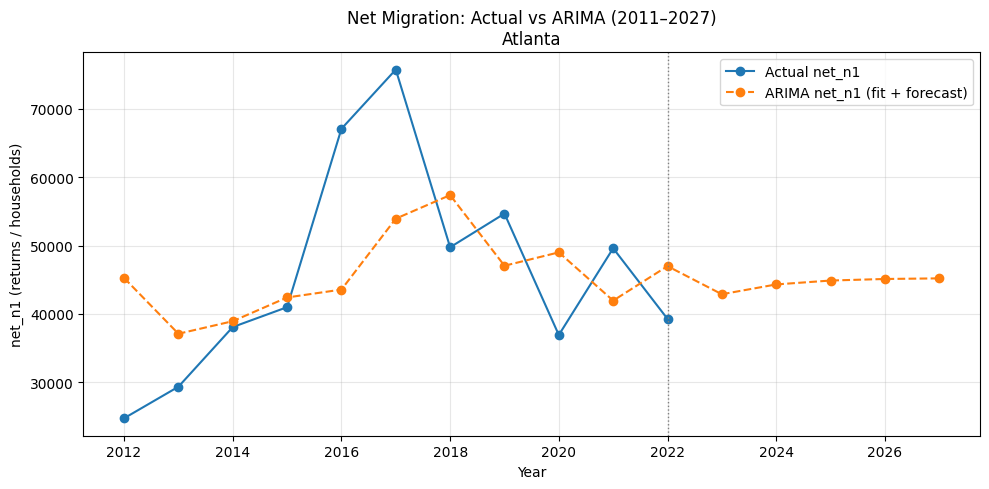

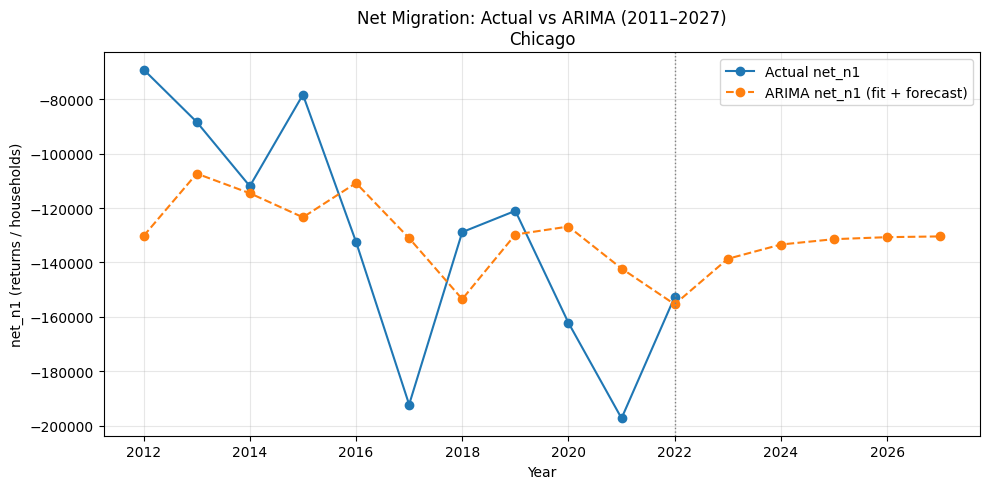

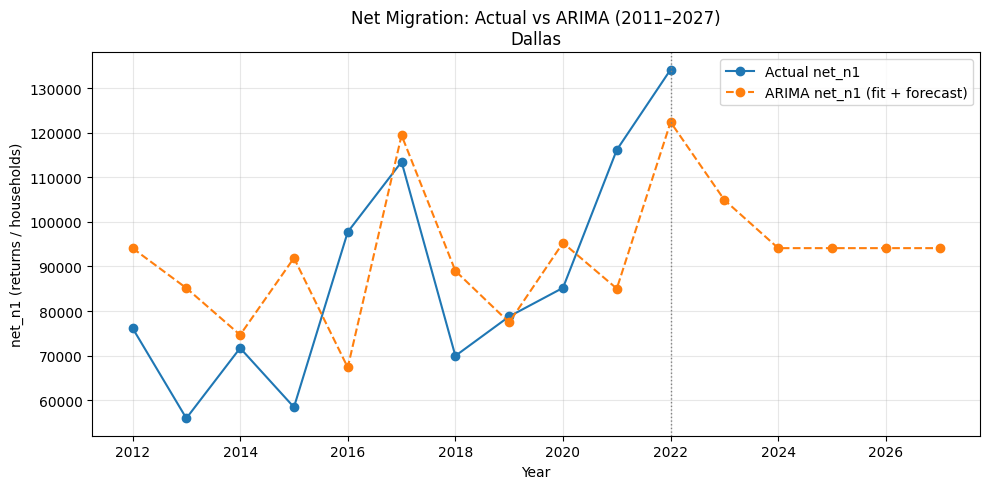

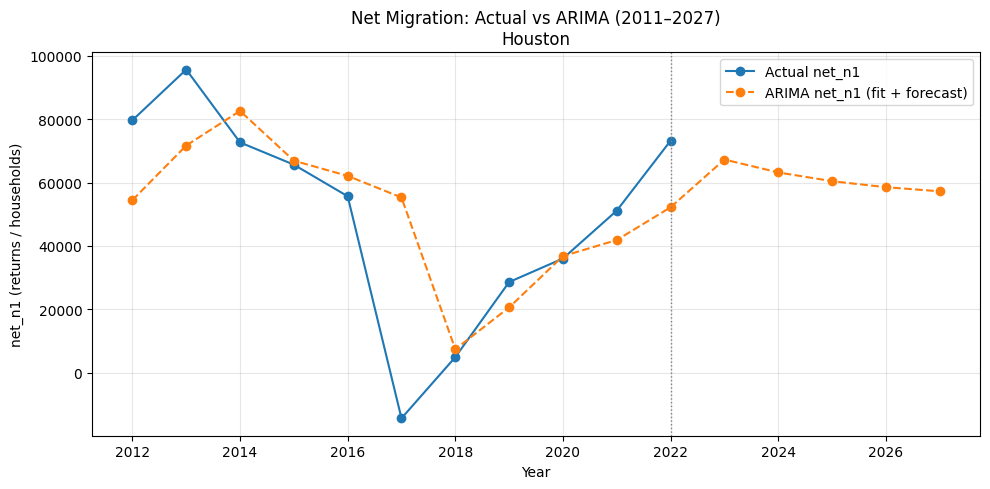

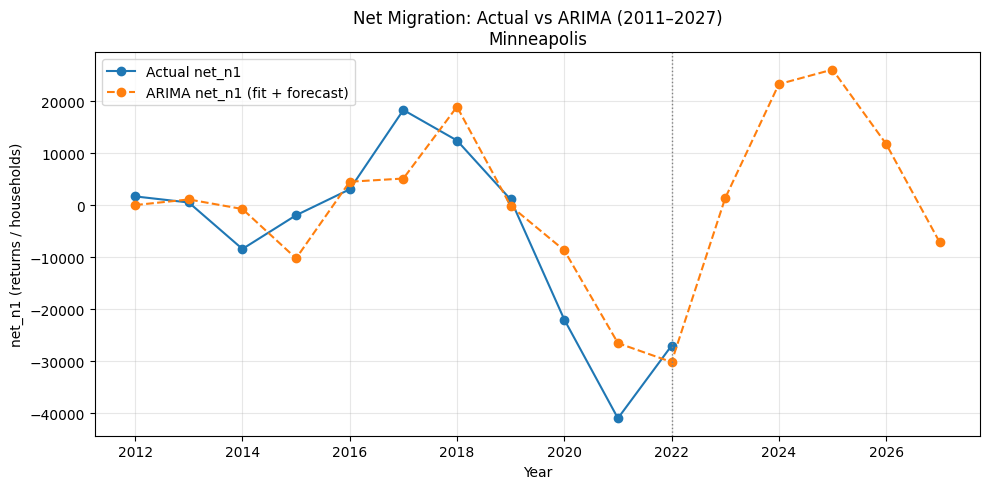

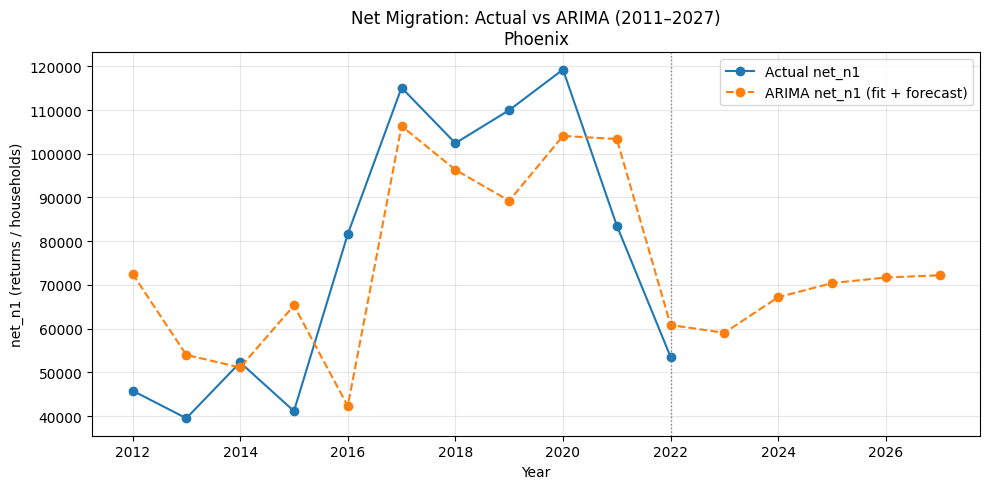

In [102]:
for metro in sorted(df_arima["metro"].unique()):
    sub = df_arima[df_arima["metro"] == metro].copy()
    sub = sub[sub["year"] >= 2011]

    hist = sub[sub["is_forecast"] == 0]
    model_line = sub  # fit + forecast

    plt.figure(figsize=(10, 5))

    # Actual net_n1
    plt.plot(
        hist["year"],
        hist["actual_net_n1"],
        marker="o",
        linestyle="-",
        label="Actual net_n1"
    )

    # ARIMA (fit + forecast)
    plt.plot(
        model_line["year"],
        model_line["arima_net_n1"],
        marker="o",
        linestyle="--",
        label="ARIMA net_n1 (fit + forecast)"
    )

    # Last actual year
    if not hist.empty:
        last_hist_year = hist["year"].max()
        plt.axvline(x=last_hist_year, color="gray", linestyle=":", linewidth=1)

    plt.title(f"Net Migration: Actual vs ARIMA (2011–2027)\n{metro}")
    plt.xlabel("Year")
    plt.ylabel("net_n1 (returns / households)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

***Trying Hybrid model - Holt and Arima***

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

# ------------------ ASSUMPTIONS ABOUT df ------------------
# df has one row per metro-year (historical only, 2011–2022):
# columns: ["year","metro","inflow_n1","outflow_n1","net_n1"]

for col in ["inflow_n1", "outflow_n1", "net_n1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

future_years = [2023, 2024, 2025, 2026, 2027]

# ------------------------------------------------------------------
# 1. RUN HOLT AND ARIMA FOR EACH METRO AND STANDARDIZE OUTPUT SHAPE
# ------------------------------------------------------------------
holt_rows  = []
arima_rows = []

for metro in sorted(df["metro"].unique()):
    sub = df[df["metro"] == metro].sort_values("year").copy()
    years_hist = sub["year"].values
    y = sub["net_n1"].values

    # ---------- HOLT (ETS A,A,N) ----------
    idx = pd.to_datetime(sub["year"].astype(str) + "-12-31")
    s = pd.Series(y, index=idx)

    holt_model = ExponentialSmoothing(
        s,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    ).fit(optimized=True)

    holt_fitted = holt_model.fittedvalues
    holt_fc = holt_model.forecast(len(future_years))

    # historical
    for t, year, inflow, outflow, actual, fit in zip(
        s.index,
        years_hist,
        sub["inflow_n1"].values,
        sub["outflow_n1"].values,
        sub["net_n1"].values,
        holt_fitted,
    ):
        if actual != 0 and not np.isnan(actual):
            err_pct = abs(actual - fit) / abs(actual) * 100
        else:
            err_pct = np.nan

        holt_rows.append({
            "metro": metro,
            "year": int(year),
            "inflow": float(inflow),
            "outflow": float(outflow),
            "actual_net_n1": float(actual),
            "pred_net_n1": float(fit),
            "error_pct": float(err_pct),
            "is_forecast": 0,
            "model": "holt"
        })

    # future
    for dt, year, fc in zip(holt_fc.index, future_years, holt_fc.values):
        holt_rows.append({
            "metro": metro,
            "year": int(year),
            "inflow": np.nan,
            "outflow": np.nan,
            "actual_net_n1": np.nan,
            "pred_net_n1": float(fc),
            "error_pct": np.nan,
            "is_forecast": 1,
            "model": "holt"
        })

    # ---------- ARIMA ----------
    arima_model = pm.auto_arima(
        y,
        start_p=1, start_q=1,
        max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )

    arima_fitted = arima_model.predict_in_sample()
    arima_fc = arima_model.predict(n_periods=len(future_years))

    # historical
    for year, inflow, outflow, actual, fit in zip(
        years_hist,
        sub["inflow_n1"].values,
        sub["outflow_n1"].values,
        sub["net_n1"].values,
        arima_fitted,
    ):
        if actual != 0 and not np.isnan(actual):
            err_pct = abs(actual - fit) / abs(actual) * 100
        else:
            err_pct = np.nan

        arima_rows.append({
            "metro": metro,
            "year": int(year),
            "inflow": float(inflow),
            "outflow": float(outflow),
            "actual_net_n1": float(actual),
            "pred_net_n1": float(fit),
            "error_pct": float(err_pct),
            "is_forecast": 0,
            "model": "arima"
        })

    # future
    for year, fc in zip(future_years, arima_fc):
        arima_rows.append({
            "metro": metro,
            "year": int(year),
            "inflow": np.nan,
            "outflow": np.nan,
            "actual_net_n1": np.nan,
            "pred_net_n1": float(fc),
            "error_pct": np.nan,
            "is_forecast": 1,
            "model": "arima"
        })

df_holt  = pd.DataFrame(holt_rows)
df_arima = pd.DataFrame(arima_rows)

# ------------------------------------------------------------------
# 2. PICK BEST MODEL PER METRO BASED ON HISTORICAL MAPE
# ------------------------------------------------------------------
model_choices = []

for metro in sorted(df["metro"].unique()):
    h_hist = df_holt[(df_holt["metro"] == metro) & (df_holt["is_forecast"] == 0)]
    a_hist = df_arima[(df_arima["metro"] == metro) & (df_arima["is_forecast"] == 0)]

    mape_holt  = h_hist["error_pct"].mean()
    mape_arima = a_hist["error_pct"].mean()

    best_model = "holt" if mape_holt <= mape_arima else "arima"

    model_choices.append({
        "metro": metro,
        "mape_holt": mape_holt,
        "mape_arima": mape_arima,
        "best_model": best_model
    })

df_model_choice = pd.DataFrame(model_choices)
print(df_model_choice)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Fra

         metro   mape_holt  mape_arima best_model
0      Atlanta   24.719331   25.155011       holt
1      Chicago   15.625057   26.906998       holt
2       Dallas   19.680155   22.704503       holt
3      Houston  104.187918   63.367085      arima
4  Minneapolis  244.467454  102.699568      arima
5      Phoenix   25.683361   26.067028       holt


In [104]:
# Merge Holt + ARIMA into one big table
df_all_models = pd.concat([df_holt, df_arima], ignore_index=True)

# Attach best_model flag
df_all_models = df_all_models.merge(
    df_model_choice[["metro", "best_model"]],
    on="metro",
    how="left"
)

# Filter rows where model == best_model
df_final = df_all_models[df_all_models["model"] == df_all_models["best_model"]].copy()

# Rename columns to your requested schema
df_final = df_final.rename(columns={
    "pred_net_n1": "final_net_n1"
})[[
    "metro",
    "year",
    "inflow",
    "outflow",
    "actual_net_n1",
    "final_net_n1",
    "error_pct",
    "is_forecast",
    "model"        # which model was used
]].sort_values(["metro", "year"]).reset_index(drop=True)

print(df_final.head())

     metro  year    inflow   outflow  actual_net_n1  final_net_n1  error_pct  \
0  Atlanta  2012  883953.0  859266.0        24687.0  33510.155814  35.740089   
1  Atlanta  2013  831591.0  802282.0        29309.0  27282.166933   6.915395   
2  Atlanta  2014  774438.0  736385.0        38053.0  29580.259146  22.265632   
3  Atlanta  2015  625011.0  584046.0        40965.0  36943.640653   9.816574   
4  Atlanta  2016  801770.0  734673.0        67097.0  40809.060999  39.179008   

   is_forecast model  
0            0  holt  
1            0  holt  
2            0  holt  
3            0  holt  
4            0  holt  


In [105]:
out_file = "metro_migration_hybrid_2011_2027.xlsx"
df_final.to_excel(out_file, index=False)
print(f"Saved hybrid (Holt/ARIMA) migration forecast to: {out_file}")

Saved hybrid (Holt/ARIMA) migration forecast to: metro_migration_hybrid_2011_2027.xlsx


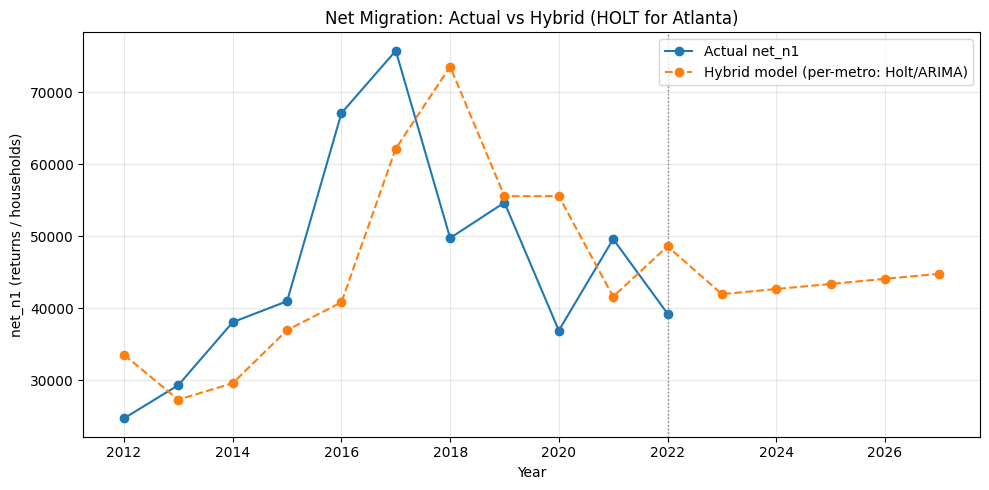

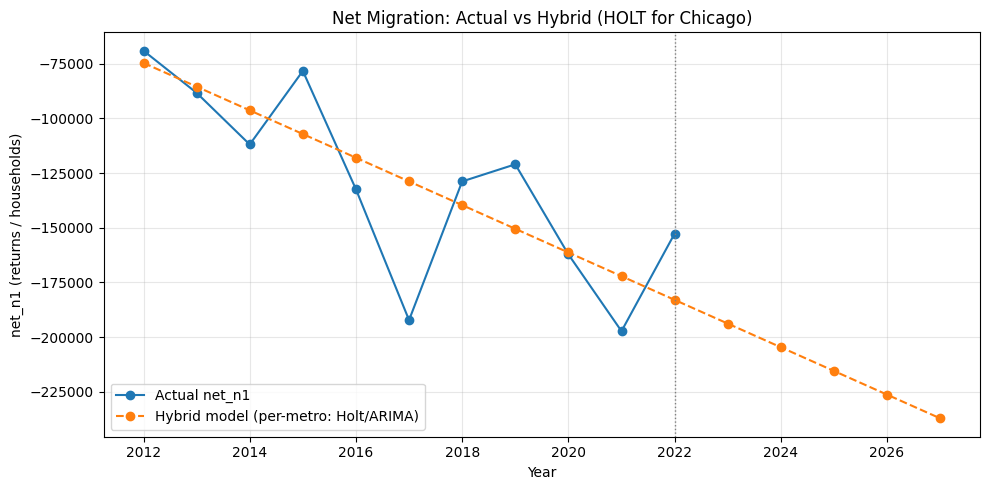

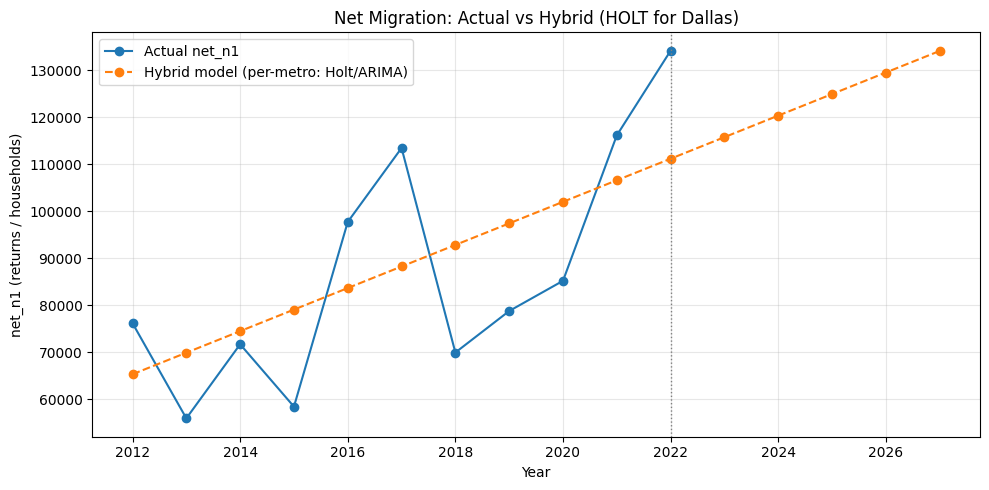

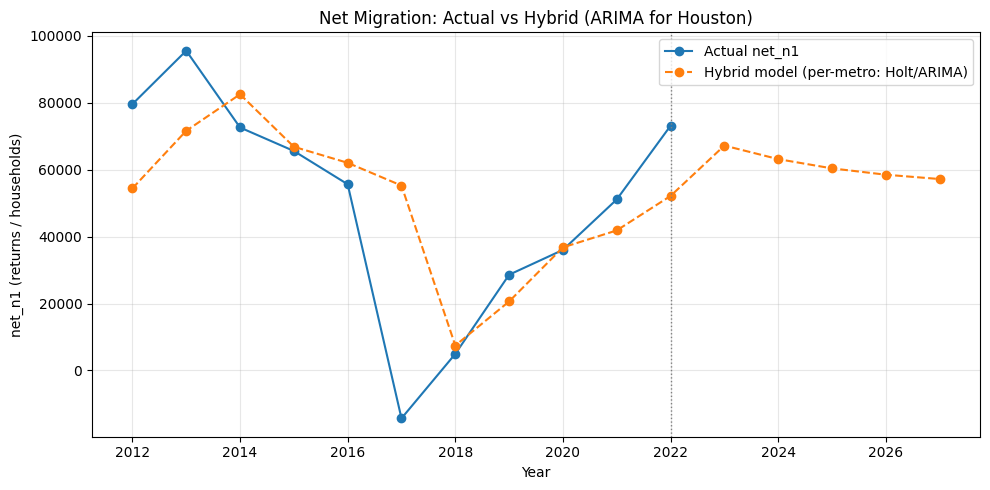

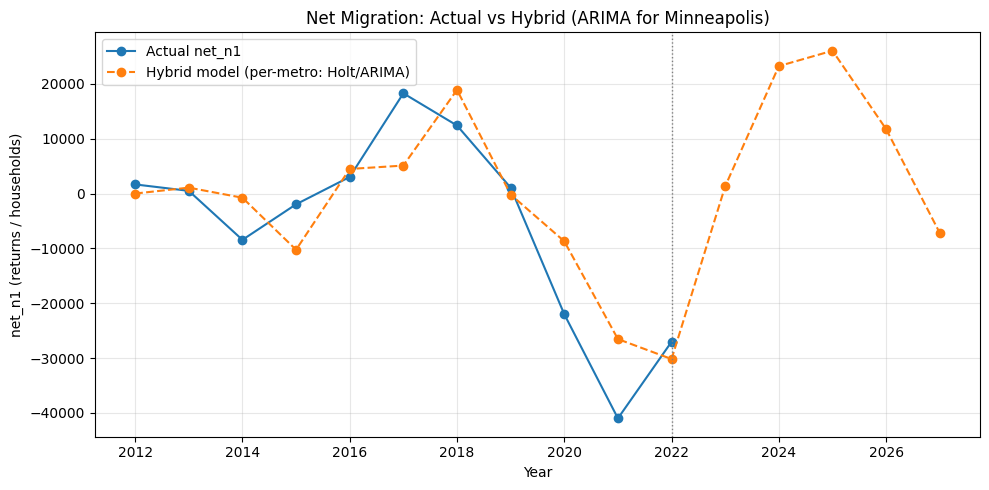

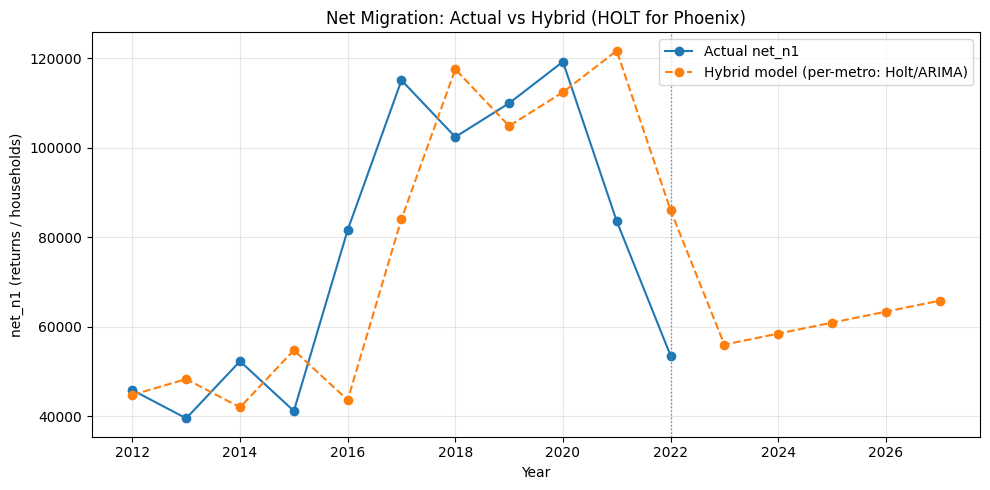

In [106]:
for metro in sorted(df_final["metro"].unique()):
    sub = df_final[df_final["metro"] == metro].copy()
    sub = sub[sub["year"] >= 2011]

    hist = sub[sub["is_forecast"] == 0]
    model_line = sub  # chosen model fit + forecast

    plt.figure(figsize=(10, 5))

    # Actual net_n1
    plt.plot(
        hist["year"],
        hist["actual_net_n1"],
        marker="o",
        linestyle="-",
        label="Actual net_n1"
    )

    # Hybrid model (Holt or ARIMA)
    plt.plot(
        model_line["year"],
        model_line["final_net_n1"],
        marker="o",
        linestyle="--",
        label=f"Hybrid model (per-metro: Holt/ARIMA)"
    )

    # Last actual year
    if not hist.empty:
        last_hist_year = hist["year"].max()
        plt.axvline(x=last_hist_year, color="gray", linestyle=":", linewidth=1)

    best_model = df_model_choice[df_model_choice["metro"] == metro]["best_model"].iloc[0]
    plt.title(f"Net Migration: Actual vs Hybrid ({best_model.upper()} for {metro})")
    plt.xlabel("Year")
    plt.ylabel("net_n1 (returns / households)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

***Trying hybrid model- Holt (ETS A,A,N), Auto-ARIMA, Tuned Prophet (aggressive changepoints)***

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

# Prophet import – use the one that works in your env
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# ------------------ CONFIG ------------------
future_years = [2023, 2024, 2025, 2026, 2027]

# ------------------ CLEAN INPUT DF ------------------
for col in ["inflow_n1", "outflow_n1", "net_n1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["net_n1"]).copy()

# ------------------ HELPERS ------------------
def mape(series_actual, series_pred):
    """Mean Absolute Percentage Error, ignoring zeros and NaNs."""
    a = np.array(series_actual, dtype=float)
    p = np.array(series_pred, dtype=float)
    mask = (~np.isnan(a)) & (~np.isnan(p)) & (a != 0)
    if mask.sum() == 0:
        return np.inf
    return np.mean(np.abs(a[mask] - p[mask]) / np.abs(a[mask])) * 100.0

# Containers
rows_all_models = []      # all predictions from all models
model_summaries = []      # MAPE per metro/model


In [108]:
# ------------------ 1. FIT 3 MODELS PER METRO ------------------
for metro in sorted(df["metro"].unique()):
    sub = df[df["metro"] == metro].sort_values("year").copy()
    years_hist = sub["year"].values
    y = sub["net_n1"].values
    inflow_hist = sub["inflow_n1"].values
    outflow_hist = sub["outflow_n1"].values

    # Skip metros with too few points
    if len(sub) < 6:
        print(f"[WARN] Skipping {metro}: too few data points ({len(sub)})")
        continue

    # Common time index for Holt
    idx = pd.to_datetime(sub["year"].astype(str) + "-12-31")
    series = pd.Series(y, index=idx)

    # ----- HOLT (ETS A,A,N) -----
    holt_model = ExponentialSmoothing(
        series,
        trend="add",
        seasonal=None,
        initialization_method="estimated",
    ).fit(optimized=True)

    holt_fitted = holt_model.fittedvalues
    holt_fc = holt_model.forecast(len(future_years))

    # Store Holt rows
    for t, year, inflow, outflow, actual, pred in zip(
        series.index, years_hist, inflow_hist, outflow_hist, y, holt_fitted
    ):
        rows_all_models.append({
            "metro": metro,
            "year": int(year),
            "inflow": float(inflow),
            "outflow": float(outflow),
            "actual_net_n1": float(actual),
            "pred_net_n1": float(pred),
            "is_forecast": 0,
            "model": "holt",
        })
    for dt, year, pred in zip(holt_fc.index, future_years, holt_fc.values):
        rows_all_models.append({
            "metro": metro,
            "year": int(year),
            "inflow": np.nan,
            "outflow": np.nan,
            "actual_net_n1": np.nan,
            "pred_net_n1": float(pred),
            "is_forecast": 1,
            "model": "holt",
        })

    # ----- ARIMA -----
    arima_model = pm.auto_arima(
        y,
        start_p=1, start_q=1,
        max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
    )
    arima_fitted = arima_model.predict_in_sample()
    arima_fc = arima_model.predict(n_periods=len(future_years))

    for year, inflow, outflow, actual, pred in zip(
        years_hist, inflow_hist, outflow_hist, y, arima_fitted
    ):
        rows_all_models.append({
            "metro": metro,
            "year": int(year),
            "inflow": float(inflow),
            "outflow": float(outflow),
            "actual_net_n1": float(actual),
            "pred_net_n1": float(pred),
            "is_forecast": 0,
            "model": "arima",
        })
    for year, pred in zip(future_years, arima_fc):
        rows_all_models.append({
            "metro": metro,
            "year": int(year),
            "inflow": np.nan,
            "outflow": np.nan,
            "actual_net_n1": np.nan,
            "pred_net_n1": float(pred),
            "is_forecast": 1,
            "model": "arima",
        })

    # ----- TUNED PROPHET -----
    df_p = pd.DataFrame({
        "ds": pd.to_datetime(sub["year"].astype(str) + "-12-31"),
        "y": y,
    })

    prophet_model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        n_changepoints=10,            # more flexibility
        changepoint_prior_scale=0.5,  # more aggressive trend changes
    )
    prophet_model.fit(df_p)

    last_year = sub["year"].max()
    periods = max(future_years) - last_year
    future_df = prophet_model.make_future_dataframe(periods=periods, freq="Y")
    fc_prophet = prophet_model.predict(future_df)
    fc_prophet["year"] = fc_prophet["ds"].dt.year

    # Map year → yhat
    yhat_map = fc_prophet.set_index("year")["yhat"].to_dict()

    for year, inflow, outflow, actual in zip(
        years_hist, inflow_hist, outflow_hist, y
    ):
        pred = float(yhat_map[year])
        rows_all_models.append({
            "metro": metro,
            "year": int(year),
            "inflow": float(inflow),
            "outflow": float(outflow),
            "actual_net_n1": float(actual),
            "pred_net_n1": pred,
            "is_forecast": 0,
            "model": "prophet",
        })

    for year in future_years:
        if year <= last_year:
            continue
        pred = float(yhat_map[year])
        rows_all_models.append({
            "metro": metro,
            "year": int(year),
            "inflow": np.nan,
            "outflow": np.nan,
            "actual_net_n1": np.nan,
            "pred_net_n1": pred,
            "is_forecast": 1,
            "model": "prophet",
        })


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
16:29:21 - cmdstanpy - INFO - Chain [1] start processing
16:29:21 - cmdstanpy - INFO - Chain [1] done processing
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
16:29:21 - cmdstanpy - INFO - Chain [1] start processing
16:29:21 - cmdstanpy - INFO - Chain [1] done processing
/Library/Frameworks/Python.framework/Versions/3.

In [109]:
# ------------------ 2. BUILD ALL-MODEL DF ------------------
df_all = pd.DataFrame(rows_all_models)

# Compute error_pct for historical rows
mask_hist = df_all["is_forecast"] == 0
denom = df_all.loc[mask_hist, "actual_net_n1"].replace(0, np.nan)
df_all["error_pct"] = np.nan
df_all.loc[mask_hist, "error_pct"] = (
    (df_all.loc[mask_hist, "actual_net_n1"] - df_all.loc[mask_hist, "pred_net_n1"])
    .abs() / denom * 100
)

In [110]:
# ------------------ 3. MODEL SELECTION (MAPE PER METRO/MODEL) ------------------
for metro in sorted(df_all["metro"].unique()):
    for model_name in ["holt", "arima", "prophet"]:
        sub = df_all[
            (df_all["metro"] == metro)
            & (df_all["model"] == model_name)
            & (df_all["is_forecast"] == 0)
        ]
        mape_val = mape(sub["actual_net_n1"], sub["pred_net_n1"])
        model_summaries.append({
            "metro": metro,
            "model": model_name,
            "mape": mape_val,
        })

df_model_summary = pd.DataFrame(model_summaries)

# Choose best model per metro
best_model_by_metro = (
    df_model_summary
    .loc[df_model_summary.groupby("metro")["mape"].idxmin()]
    .rename(columns={"model": "best_model", "mape": "best_mape"})
)

print("Model choice per metro:")
print(best_model_by_metro)


Model choice per metro:
          metro best_model   best_mape
2       Atlanta    prophet   12.094301
5       Chicago    prophet   15.505203
8        Dallas    prophet   17.384507
11      Houston    prophet   59.140230
13  Minneapolis      arima  102.699568
17      Phoenix    prophet   20.669590


In [111]:
# ------------------ 4. FILTER TO BEST MODEL & BUILD FINAL HYBRID DF ------------------
df_all = df_all.merge(best_model_by_metro[["metro", "best_model"]], on="metro", how="left")
df_final = df_all[df_all["model"] == df_all["best_model"]].copy()

df_final = df_final.rename(columns={
    "pred_net_n1": "final_net_n1",
    "best_model": "model_used"
})[[
    "metro",
    "year",
    "inflow",
    "outflow",
    "actual_net_n1",
    "final_net_n1",
    "error_pct",
    "is_forecast",
    "model_used",
]]

df_final = df_final.sort_values(["metro", "year"]).reset_index(drop=True)

print("\nHybrid sample:")
print(df_final.head())


Hybrid sample:
     metro  year    inflow   outflow  actual_net_n1  final_net_n1  error_pct  \
0  Atlanta  2012  883953.0  859266.0        24687.0  23550.786522   4.602477   
1  Atlanta  2013  831591.0  802282.0        29309.0  31783.061035   8.441301   
2  Atlanta  2014  774438.0  736385.0        38053.0  40015.335308   5.156848   
3  Atlanta  2015  625011.0  584046.0        40965.0  48247.609257  17.777638   
4  Atlanta  2016  801770.0  734673.0        67097.0  56502.437100  15.789920   

   is_forecast model_used  
0            0    prophet  
1            0    prophet  
2            0    prophet  
3            0    prophet  
4            0    prophet  


In [112]:
# ------------------ 5. SAVE TO EXCEL ------------------
out_file = "metro_migration_hybrid_v2_2011_2027.xlsx"
df_final.to_excel(out_file, index=False)
print(f"\nSaved Hybrid 2.0 (Holt/ARIMA/Prophet) to: {out_file}")


Saved Hybrid 2.0 (Holt/ARIMA/Prophet) to: metro_migration_hybrid_v2_2011_2027.xlsx


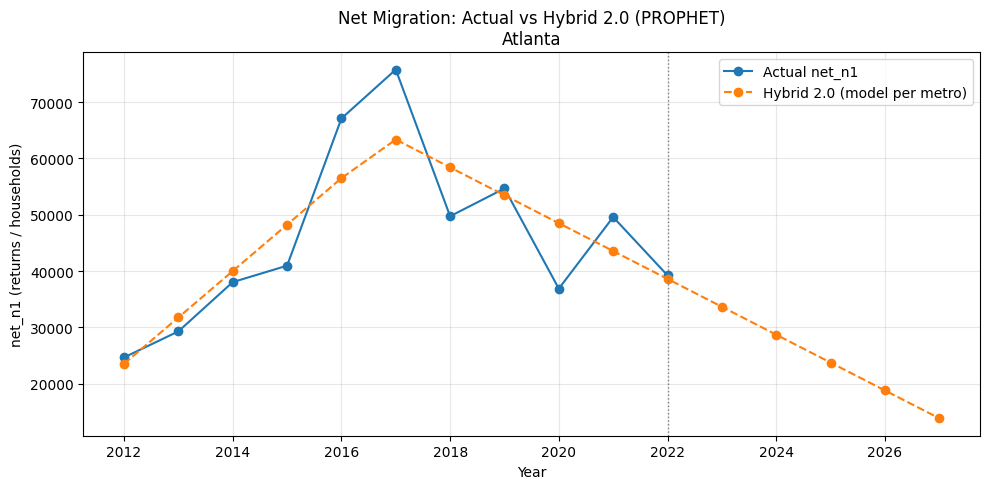

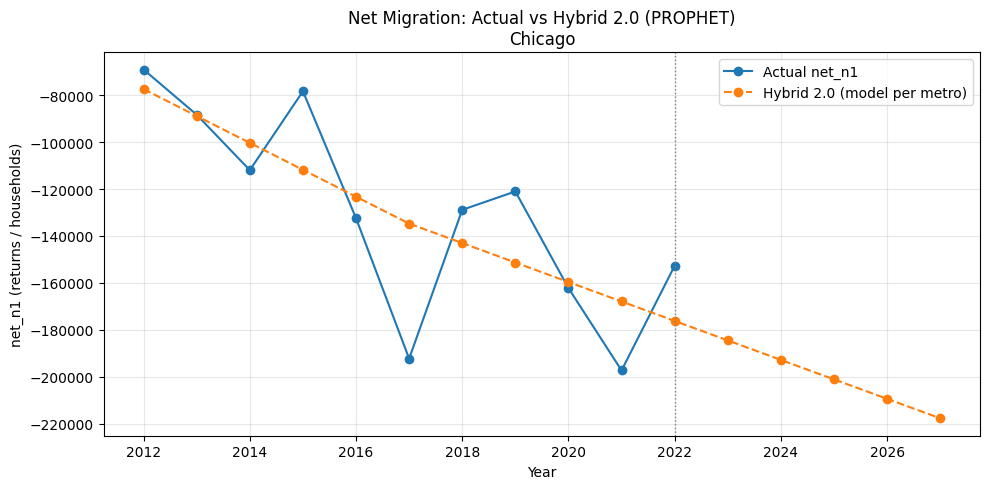

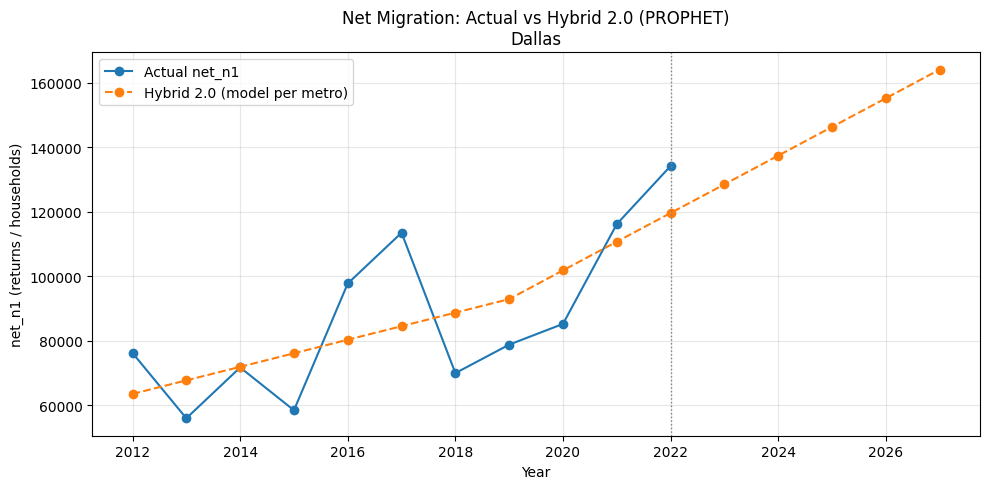

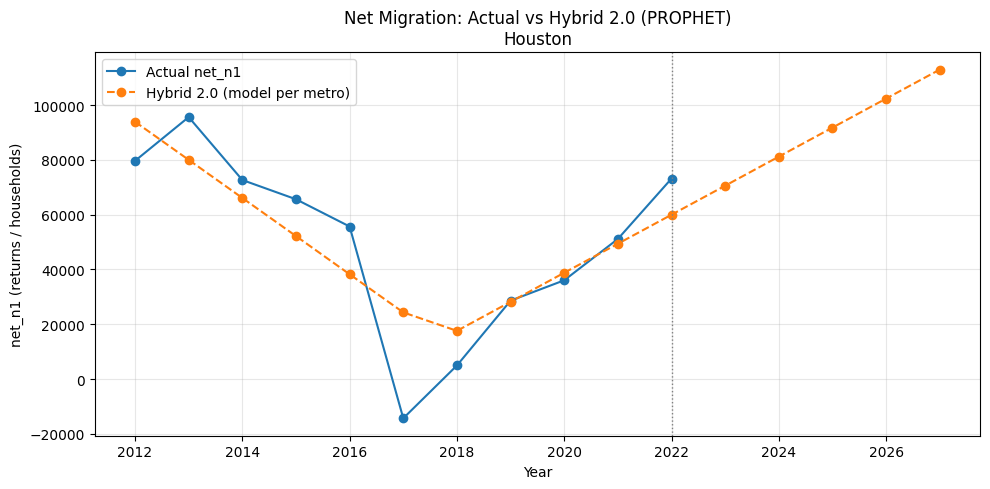

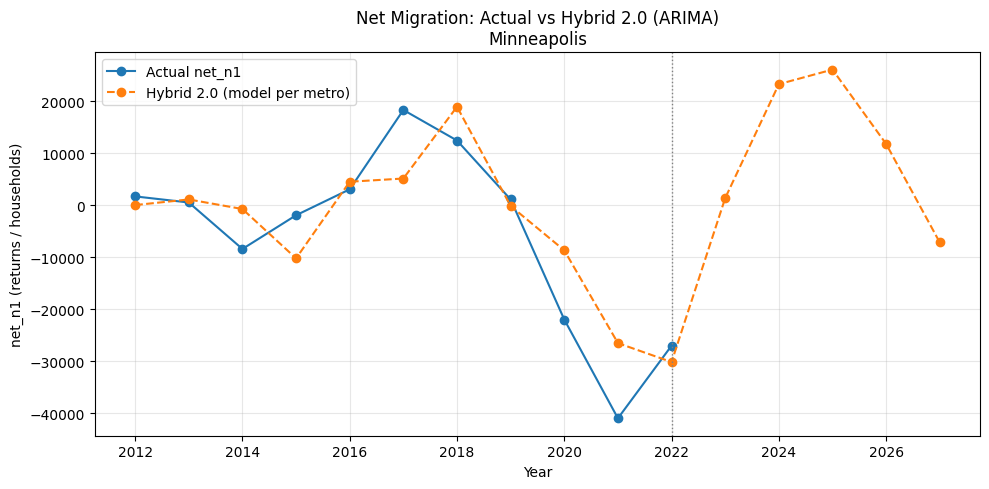

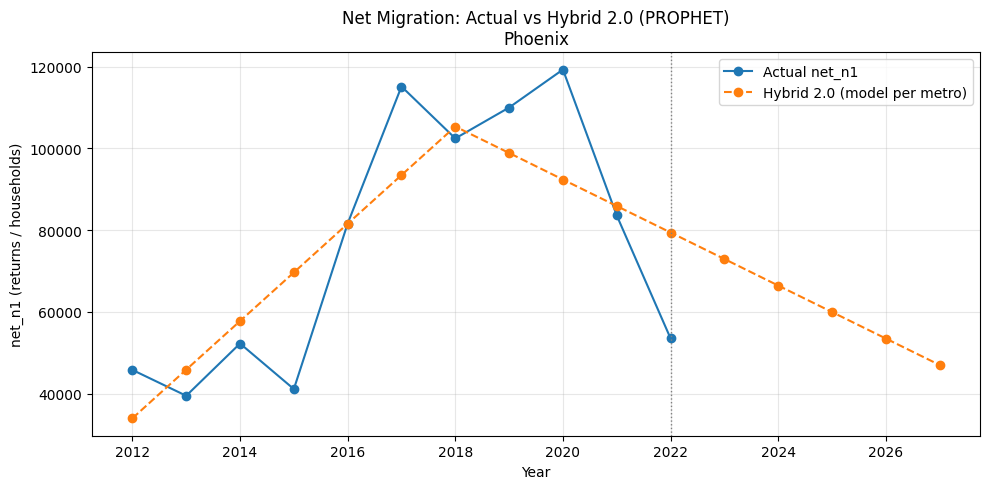

In [113]:
# ------------------ 6. PLOTS: ACTUAL VS HYBRID MODEL ------------------
for metro in sorted(df_final["metro"].unique()):
    sub = df_final[df_final["metro"] == metro].copy()
    sub = sub[sub["year"] >= 2011]

    hist = sub[sub["is_forecast"] == 0]
    model_line = sub

    plt.figure(figsize=(10, 5))

    # Actual
    plt.plot(
        hist["year"],
        hist["actual_net_n1"],
        marker="o",
        linestyle="-",
        label="Actual net_n1",
    )

    # Hybrid model
    plt.plot(
        model_line["year"],
        model_line["final_net_n1"],
        marker="o",
        linestyle="--",
        label=f"Hybrid 2.0 (model per metro)",
    )

    if not hist.empty:
        last_hist_year = hist["year"].max()
        plt.axvline(x=last_hist_year, color="gray", linestyle=":", linewidth=1)

    model_used = best_model_by_metro[best_model_by_metro["metro"] == metro]["best_model"].iloc[0]
    plt.title(f"Net Migration: Actual vs Hybrid 2.0 ({model_used.upper()})\n{metro}")
    plt.xlabel("Year")
    plt.ylabel("net_n1 (returns / households)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

***Population Forecast***

In [114]:
import os
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ---------------- CONFIG ----------------
METRO_DIR = "Metros"     # folder with 2010_Metros.csv ... 2024_Metros.csv
YEARS = list(range(2010, 2025))   # 2010–2024 actuals
FUTURE_YEARS = [2025, 2026, 2027]

POP_COL = "S0701_C01_001E"   # Population 1 year and over

# CBSA → stable metro label (you control these names)
CBSA_NAME = {
    "12060": "Atlanta Metro",
    "16980": "Chicago Metro",
    "19100": "Dallas Metro",
    "26420": "Houston Metro",
    "33460": "Minneapolis Metro",
    "38060": "Phoenix Metro",
}
CBSA_CODES = set(CBSA_NAME.keys())

In [115]:
# ---------------- 1) LOAD POPULATION DATA USING CBSA ----------------
rows = []

for year in YEARS:
    fname = f"{year}_Metros.csv"
    path = os.path.join(METRO_DIR, fname)
    if not os.path.exists(path):
        print(f"[WARN] Missing file: {path}, skipping this year.")
        continue

    # Read CSV (first row: GEO_ID, NAME, S0701_C01_001E, ...)
    df = pd.read_csv(path, dtype=str)
    df.columns = df.columns.str.strip()

    needed = ["GEO_ID", POP_COL]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns {missing} in {fname}. "
            f"Columns detected: {df.columns.tolist()}"
        )

    # Extract CBSA from GEO_ID (last 5 digits)
    df["cbsa"] = (
        df["GEO_ID"]
        .astype(str)
        .str.extract(r"(\d{5})$", expand=False)
    )

    # Filter just the 6 metros by CBSA
    df_sub = df[df["cbsa"].isin(CBSA_CODES)].copy()
    print(f"Year {year}: rows matching our CBSAs = {len(df_sub)}")

    if df_sub.empty:
        print(f"[WARN] No target CBSAs found in {fname}")
        continue

    # Add stable metro name
    df_sub["metro"] = df_sub["cbsa"].map(CBSA_NAME)

    # Convert population to numeric
    df_sub[POP_COL] = pd.to_numeric(df_sub[POP_COL], errors="coerce")

    for _, row in df_sub.iterrows():
        rows.append({
            "year": year,
            "cbsa": row["cbsa"],
            "metro": row["metro"],
            "population": float(row[POP_COL])
        })

df_pop = pd.DataFrame(rows)

if df_pop.empty:
    raise RuntimeError("No population data loaded. Check CBSA extraction and file structure.")

df_pop = df_pop.sort_values(["cbsa", "year"]).reset_index(drop=True)
print("\nSample of combined population data:")
print(df_pop.head())

Year 2010: rows matching our CBSAs = 6
Year 2011: rows matching our CBSAs = 6
Year 2012: rows matching our CBSAs = 6
Year 2013: rows matching our CBSAs = 6
Year 2014: rows matching our CBSAs = 6
Year 2015: rows matching our CBSAs = 6
Year 2016: rows matching our CBSAs = 6
Year 2017: rows matching our CBSAs = 6
Year 2018: rows matching our CBSAs = 6
Year 2019: rows matching our CBSAs = 6
Year 2020: rows matching our CBSAs = 6
Year 2021: rows matching our CBSAs = 6
Year 2022: rows matching our CBSAs = 6
Year 2023: rows matching our CBSAs = 6
Year 2024: rows matching our CBSAs = 6

Sample of combined population data:
   year   cbsa          metro  population
0  2010  12060  Atlanta Metro   5052645.0
1  2011  12060  Atlanta Metro   5142626.0
2  2012  12060  Atlanta Metro   5220828.0
3  2013  12060  Atlanta Metro   5308991.0
4  2014  12060  Atlanta Metro   5386650.0


In [116]:
# ---------------- 2) HOLT-WINTERS DAMPED TREND (ETS(A, Ad, N)) ----------------
records = []

for cbsa in sorted(df_pop["cbsa"].unique()):
    sub = df_pop[df_pop["cbsa"] == cbsa].sort_values("year")
    years = sub["year"].values
    y = sub["population"].values
    metro_name = sub["metro"].iloc[0]

    # Build annual DateTime index
    idx = pd.to_datetime(sub["year"].astype(str) + "-12-31")
    s = pd.Series(y, index=idx)

    # 🔹 DAMPED Holt's Linear: ETS(A, Ad, N)
    model = ExponentialSmoothing(
        s,
        trend="add",
        damped_trend=True,   # <-- this is the key change
        seasonal=None,
        initialization_method="estimated"
    ).fit(optimized=True)

    fitted = model.fittedvalues

    # Store historical (actual + fitted)
    for t, year, actual, fit in zip(s.index, years, y, fitted):
        records.append({
            "metro": metro_name,
            "cbsa": cbsa,
            "year": int(year),
            "population_actual": float(actual),
            "population_holt_damped": float(fit),
            "is_forecast": 0
        })

    # Forecast future years 2025–2027
    steps = len(FUTURE_YEARS)
    fc = model.forecast(steps)

    for dt, year, val in zip(fc.index, FUTURE_YEARS, fc.values):
        records.append({
            "metro": metro_name,
            "cbsa": cbsa,
            "year": int(year),
            "population_actual": np.nan,
            "population_holt_damped": float(val),
            "is_forecast": 1
        })

df_pop_forecast = (
    pd.DataFrame(records)
    .sort_values(["cbsa", "year"])
    .reset_index(drop=True)
)

print("\nPreview 2022–2027 (damped Holt):")
print(df_pop_forecast[df_pop_forecast["year"] >= 2022])


Preview 2022–2027 (damped Holt):
                 metro   cbsa  year  population_actual  \
12       Atlanta Metro  12060  2022          6031600.0   
13       Atlanta Metro  12060  2023          6111717.0   
14       Atlanta Metro  12060  2024          6336896.0   
15       Atlanta Metro  12060  2025                NaN   
16       Atlanta Metro  12060  2026                NaN   
17       Atlanta Metro  12060  2027                NaN   
30       Chicago Metro  16980  2022          9465861.0   
31       Chicago Metro  16980  2023          9261670.0   
32       Chicago Metro  16980  2024          9319133.0   
33       Chicago Metro  16980  2025                NaN   
34       Chicago Metro  16980  2026                NaN   
35       Chicago Metro  16980  2027                NaN   
48        Dallas Metro  19100  2022          7585032.0   
49        Dallas Metro  19100  2023          7717846.0   
50        Dallas Metro  19100  2024          8256829.0   
51        Dallas Metro  19100  2025   

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Fra

In [117]:
# ---------------- 3) APPLY BIAS CORRECTION ----------------
df_corr = []

for cbsa in df_pop_forecast["cbsa"].unique():
    sub = df_pop_forecast[df_pop_forecast["cbsa"] == cbsa].copy()
    metro = sub["metro"].iloc[0]

    # Get actual + fitted for the last historical year (2024)
    actual_2024 = sub[(sub["year"] == 2024) & (sub["is_forecast"] == 0)]["population_actual"].values
    fitted_2024 = sub[(sub["year"] == 2024) & (sub["is_forecast"] == 0)]["population_holt_damped"].values

    if len(actual_2024) == 1 and len(fitted_2024) == 1:
        scale = actual_2024[0] / fitted_2024[0]
    else:
        scale = 1.0  # fallback (should not happen)

    # Apply correction to forecasted values ONLY
    sub.loc[sub["is_forecast"] == 1, "population_holt_damped"] *= scale
    sub["bias_scale_factor"] = scale

    df_corr.append(sub)

df_pop_corrected = (
    pd.concat(df_corr, ignore_index=True)
    .sort_values(["cbsa", "year"])
)

In [118]:
# ---------------- 3) SAVE OUTPUT TO EXCEL ----------------
out_file = "metro_population_holt_damped_2010_2027_biascorrected.xlsx"
df_pop_corrected.to_excel(out_file, index=False)

print(f"\nSaved population forecasts (damped Holt) to: {out_file}")


Saved population forecasts (damped Holt) to: metro_population_holt_damped_2010_2027_biascorrected.xlsx


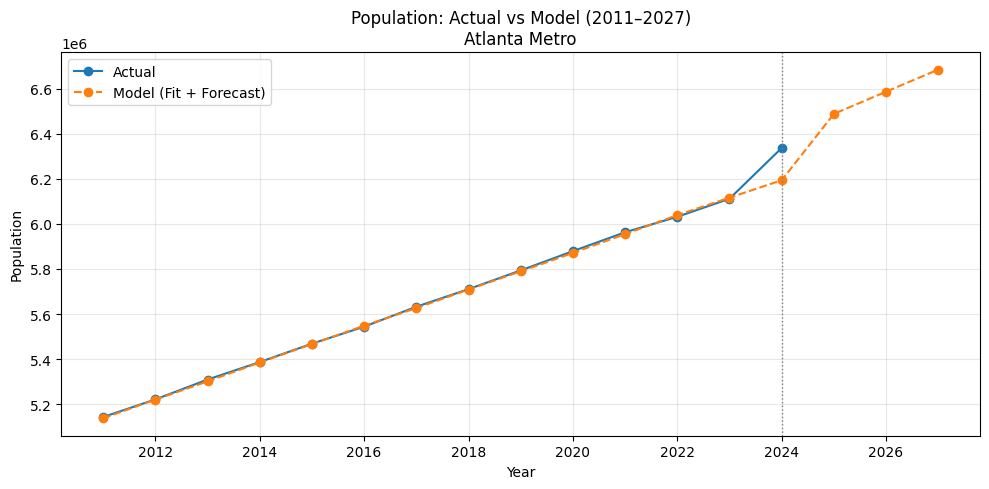

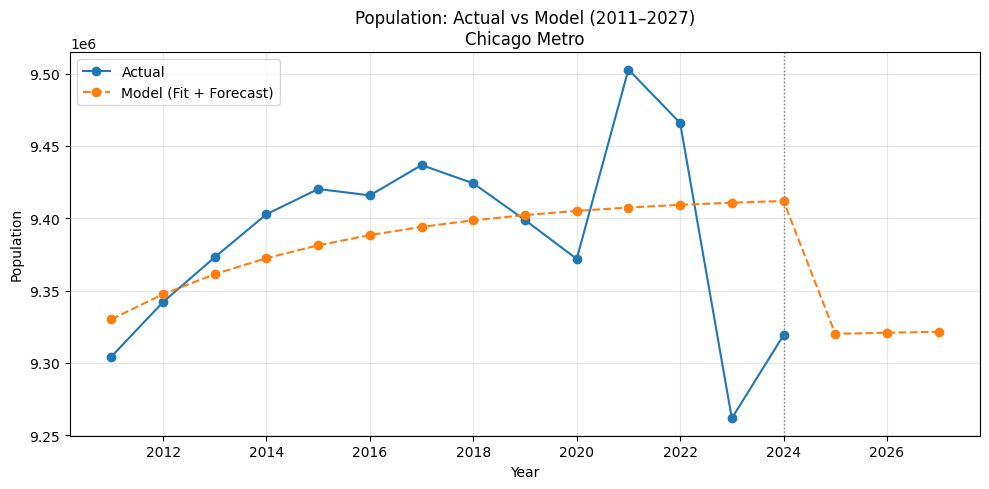

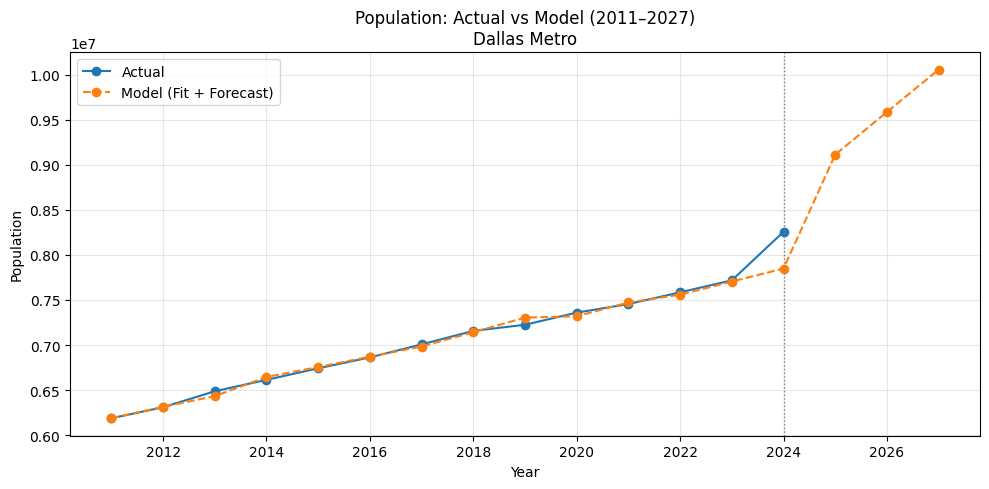

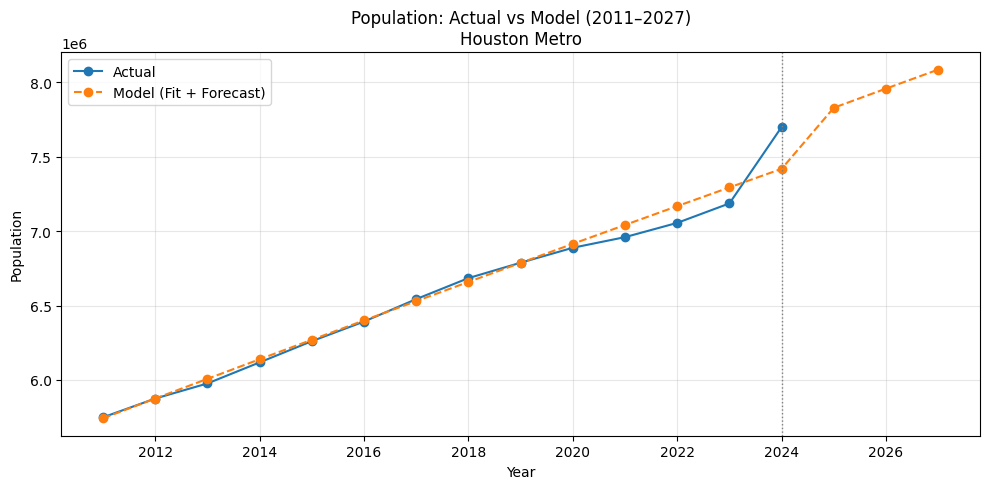

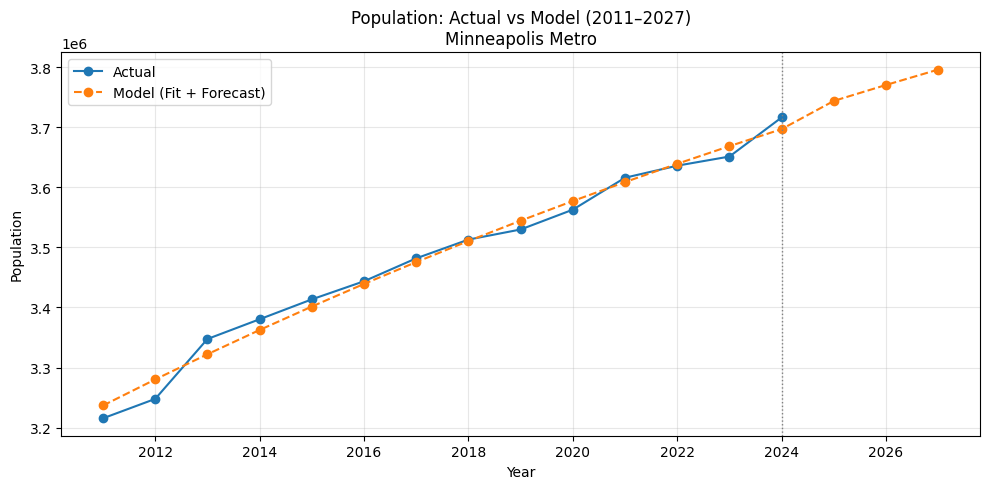

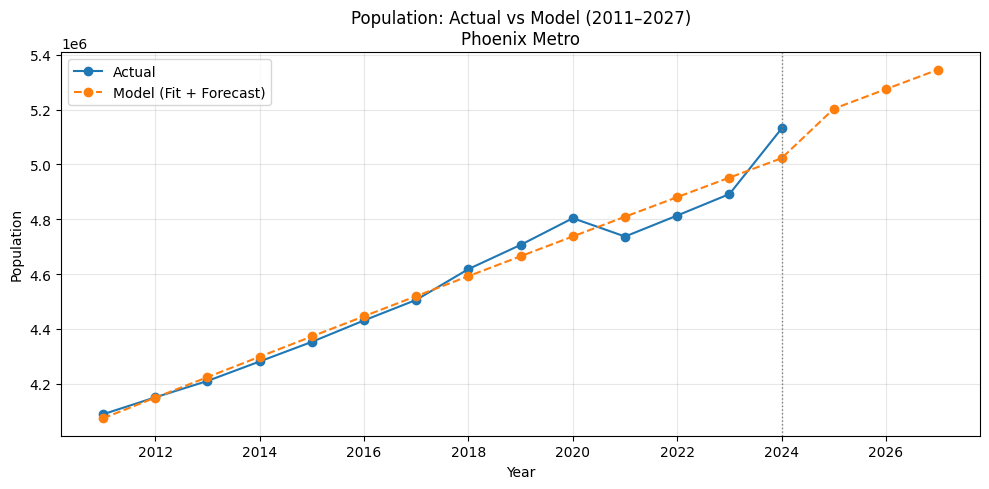

In [119]:
import matplotlib.pyplot as plt

metros = df_pop_corrected["metro"].unique()

for metro in metros:
    sub = df_pop_corrected[df_pop_corrected["metro"] == metro].copy()
    sub = sub[sub["year"] >= 2011]   # show from 2011–2027

    actual = sub[sub["is_forecast"] == 0]
    model_line = sub  # model values (fit for 2011–24 + forecast for 2025–27)

    plt.figure(figsize=(10, 5))

    # 1) Actuals: only where we have real data (2011–2024)
    plt.plot(
        actual["year"],
        actual["population_actual"],
        marker="o",
        linestyle="-",
        label="Actual"
    )

    # 2) Model: fitted (2011–24) + forecast (2025–27)
    plt.plot(
        model_line["year"],
        model_line["population_holt_damped"],
        marker="o",
        linestyle="--",
        label="Model (Fit + Forecast)"
    )

    # Optional: mark the last actual year visually
    last_hist_year = actual["year"].max()
    plt.axvline(x=last_hist_year, color="gray", linestyle=":", linewidth=1)

    plt.title(f"Population: Actual vs Model (2011–2027)\n{metro}")
    plt.xlabel("Year")
    plt.ylabel("Population")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()